# Masked Word Pretraining

# Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

seed = 42

# Prepare Training Corpus

In [2]:
sentences = [
    "the camera quality is excellent",
    "the camera performance is excellent",
    "the photo quality is excellent",
    "the image clarity is excellent",
    "the lens performance is excellent",
    "the portrait quality is excellent",
    "the video quality is excellent",
    "the camera detail is excellent",

    "the battery life is poor",
    "the battery performance is poor",
    "the charging speed is poor",
    "the power efficiency is poor",
    "the battery backup is poor",
    "the charging reliability is poor",
    "the power management is poor",
    "the battery endurance is poor",

    "the screen display is bright",
    "the screen panel is bright",
    "the display quality is bright",
    "the outdoor screen is bright",
    "the monitor display is bright",
    "the phone screen is bright",
    "the tablet display is bright",
    "the laptop screen is bright",

    "the application response is slow",
    "the app performance is slow",
    "the system startup is slow",
    "the page loading is slow",
    "the software response is slow",
    "the application startup is slow",
    "the system performance is slow",
    "the app loading is slow",
]

print("Total sentences:", len(sentences))

Total sentences: 32


# Create Masked Examples

In [3]:
def create_masked_dataset(texts, mask_token="[MASK]"):
    rows = []

    for sentence in texts:
        words = sentence.lower().split()

        if len(words) < 2:
            continue

        rows.append({
            "context": f"{' '.join(words[:-1])} {mask_token}",
            "target": words[-1],
        })

    return pd.DataFrame(rows)


# This small dataset mirrors a masked-word pretraining objective
data = create_masked_dataset(sentences)
display(data.head())

,context,target
0,the camera quality is [MASK],excellent
1,the camera performance is [MASK],excellent
2,the photo quality is [MASK],excellent
3,the image clarity is [MASK],excellent
4,the lens performance is [MASK],excellent


# Review Target Balance

In [4]:
target_summary = (
    data["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="examples")
)

display(target_summary)

,target,examples
0,excellent,8
1,poor,8
2,bright,8
3,slow,8


# Split Training Data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data["context"],
    data["target"],
    test_size=0.25,
    random_state=seed,
    stratify=data["target"],
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 24
Testing examples: 8


# Build Training Pipeline

In [6]:
model = Pipeline([
    (
        "vectorizer",
        CountVectorizer(ngram_range=(1, 2)),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=seed,
        ),
    ),
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# Train And Evaluate

In [7]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
report = pd.DataFrame(
    classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print(f"Accuracy: {accuracy:.2%}")
display(report.round(3))

Accuracy: 100.00%


,precision,recall,f1-score,support
bright,1.0,1.0,1.0,2.0
excellent,1.0,1.0,1.0,2.0
poor,1.0,1.0,1.0,2.0
slow,1.0,1.0,1.0,2.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,8.0
weighted avg,1.0,1.0,1.0,8.0


# Review Test Predictions

In [8]:
test_results = pd.DataFrame({
    "context": X_test.values,
    "actual": y_test.values,
    "predicted": predictions,
})

test_results["correct"] = (
    test_results["actual"] == test_results["predicted"]
)

display(test_results.reset_index(drop=True))

,context,actual,predicted,correct
0,the outdoor screen is [MASK],bright,bright,True
1,the page loading is [MASK],slow,slow,True
2,the app performance is [MASK],slow,slow,True
3,the camera performance is [MASK],excellent,excellent,True
4,the battery endurance is [MASK],poor,poor,True
5,the video quality is [MASK],excellent,excellent,True
6,the tablet display is [MASK],bright,bright,True
7,the charging speed is [MASK],poor,poor,True


# Predict Masked Words

In [9]:
def predict_masked_words(context, top_k=3):
    probabilities = model.predict_proba([context])[0]
    classes = model.named_steps["classifier"].classes_

    results = pd.DataFrame({
        "predicted_word": classes,
        "probability": probabilities,
    })

    return (
        results
        .sort_values("probability", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )


example = "the battery backup is [MASK]"
word_predictions = predict_masked_words(example)

print("Input:", example)
display(word_predictions)

Input: the battery backup is [MASK]


,predicted_word,probability
0,poor,0.807593
1,slow,0.065131
2,excellent,0.064707


# Visualize Prediction Confidence

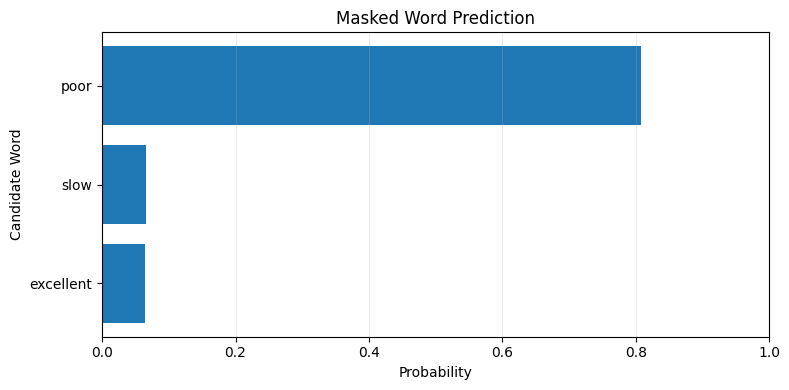

In [10]:
plot_data = word_predictions.sort_values("probability")

plt.figure(figsize=(8, 4))
plt.barh(
    plot_data["predicted_word"],
    plot_data["probability"],
)
plt.title("Masked Word Prediction")
plt.xlabel("Probability")
plt.ylabel("Candidate Word")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()